# Dados RAIS por CNAE

CNAE (Grupos):

- 01.54-7 Criação de suínos
- 01.55-5 Criação de aves
- 10.12-1 Abate de suínos, aves e outros pequenos animais


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

: 

In [57]:
import json
import pandas as pd
caminho_arquivo = '/content/drive/MyDrive/Dados_Dirceu/data.json'

df = pd.read_json(caminho_arquivo, lines=True, dtype=str)

In [58]:
df

,ano,sigla_uf,id_municipio,tipo_vinculo,vinculo_ativo_3112,id_municipio_trabalho,cbo_2002,cnae_1,cnae_2,cnae_2_subclasse,nacionalidade,sexo,raca_cor,indicador_portador_deficiencia,tipo_deficiencia,tamanho_estabelecimento,tipo_estabelecimento,indicador_simples,natureza_juridica
0,2022,SP,3509452,25,1,3509452,623305,00999,01555,0155501,10,1,9,0,0,4,2,0,nan
1,2022,SP,3509452,25,1,3509452,623305,00999,01555,0155501,10,1,9,0,0,4,2,0,nan
2,2022,SP,3509452,15,1,3509452,623305,00999,01555,0155501,10,1,9,0,0,4,2,0,nan
3,2022,SP,3509452,15,1,3509452,623305,00999,01555,0155501,10,1,9,0,0,4,2,0,nan
4,2022,MS,5002407,60,1,5002407,784205,15121,10121,1012101,10,2,8,0,0,8,1,0,2062
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1044782,2023,SC,4205506,10,1,nan,623215,9999,154,0154700,10,1,2,0,0,5,1,0,2062
1044783,2023,SP,3505807,25,1,nan,623310,9999,155,0155505,10,2,2,0,0,5,5,0,4120
1044784,2023,GO,5213103,25,1,nan,623305,9999,155,0155504,10,1,8,0,0,2,5,0,nan
1044785,2023,SP,3505807,25,1,nan,715505,9999,155,0155504,10,1,2,0,0,7,5,0,4081


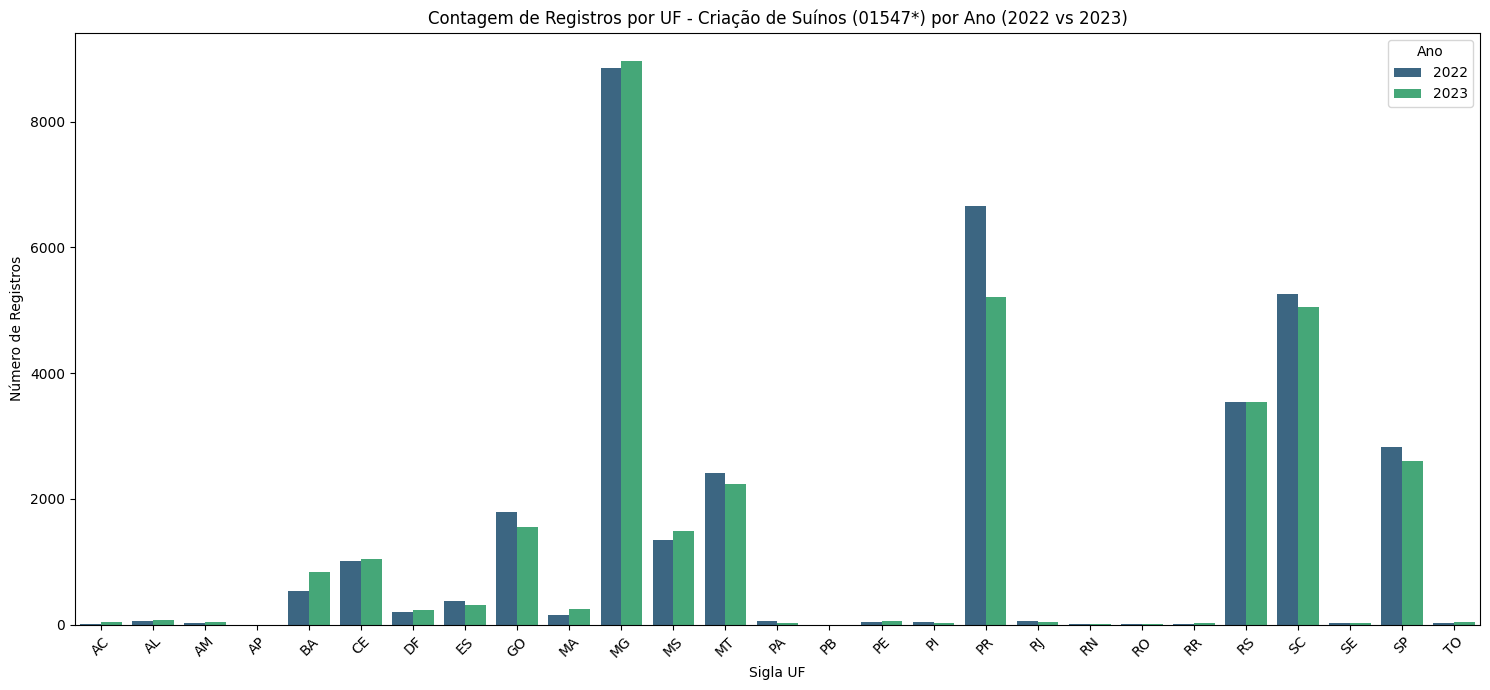

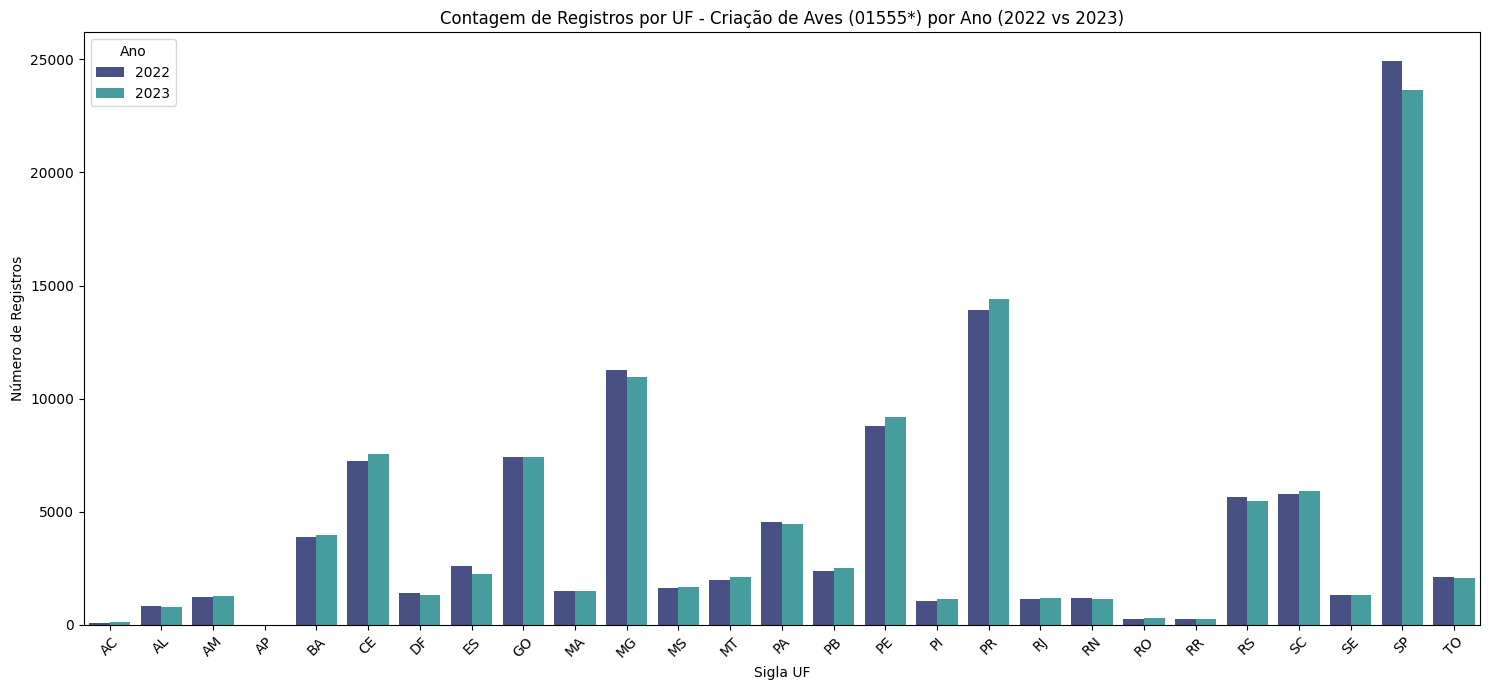

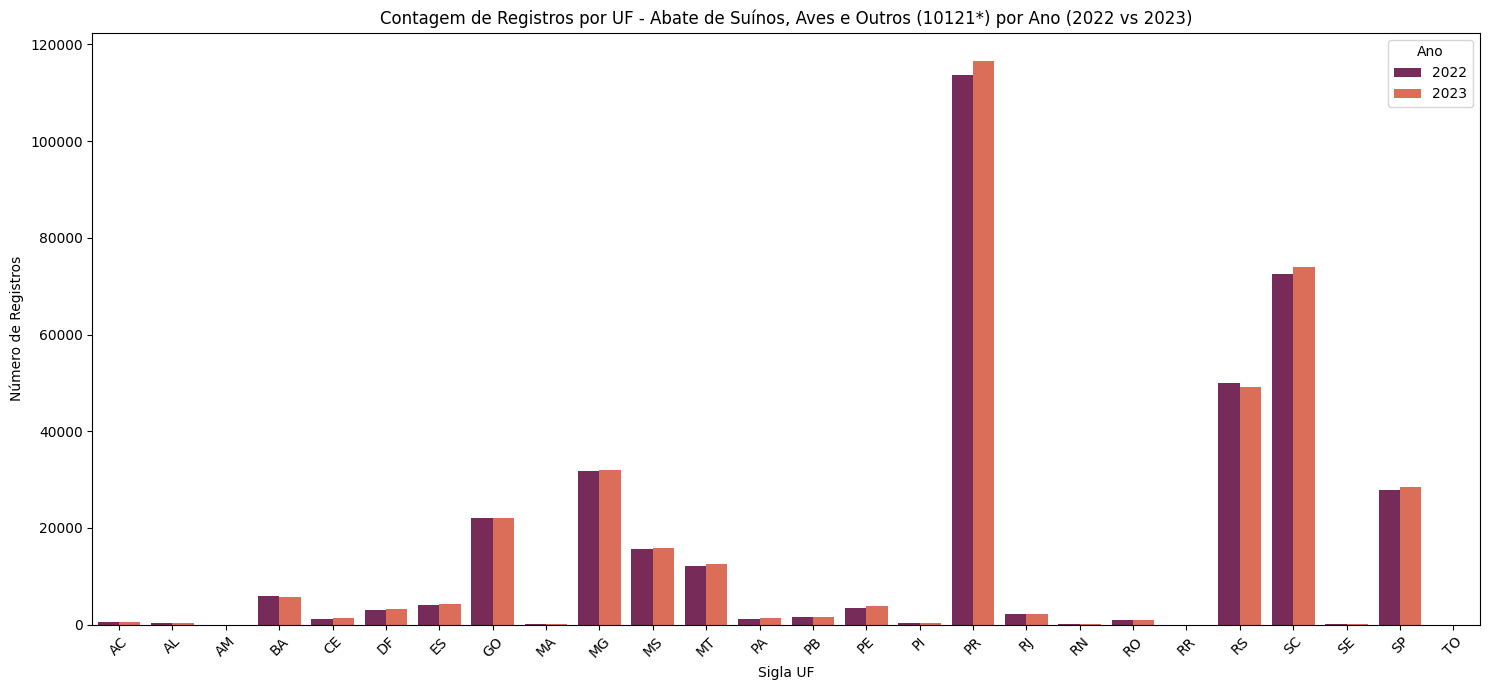

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure 'cnae_2_subclasse' is treated as a string
df['cnae_2_subclasse'] = df['cnae_2_subclasse'].astype(str)

# Gráfico 1: Contagem de Registros de Criação de Suínos (2022 vs 2023)
suinos_filtered_df = df[df['cnae_2_subclasse'].str.startswith('01547') & df['ano'].isin(["2022", "2023"])]
suinos_counts_by_year_uf = suinos_filtered_df.groupby(['sigla_uf', 'ano']).size().reset_index(name='count')

plt.figure(figsize=(15, 7))
sns.barplot(data=suinos_counts_by_year_uf, x='sigla_uf', y='count', hue='ano', palette='viridis')
plt.title('Contagem de Registros por UF - Criação de Suínos (01547*) por Ano (2022 vs 2023)')
plt.xlabel('Sigla UF')
plt.ylabel('Número de Registros')
plt.xticks(rotation=45)
plt.legend(title='Ano')
plt.tight_layout()
plt.show()

# Gráfico 2: Contagem de Registros de Criação de Aves (2022 vs 2023)
aves_filtered_df = df[df['cnae_2_subclasse'].str.startswith('01555') & df['ano'].isin(["2022", "2023"])]
aves_counts_by_year_uf = aves_filtered_df.groupby(['sigla_uf', 'ano']).size().reset_index(name='count')

plt.figure(figsize=(15, 7))
sns.barplot(data=aves_counts_by_year_uf, x='sigla_uf', y='count', hue='ano', palette='mako')
plt.title('Contagem de Registros por UF - Criação de Aves (01555*) por Ano (2022 vs 2023)')
plt.xlabel('Sigla UF')
plt.ylabel('Número de Registros')
plt.xticks(rotation=45)
plt.legend(title='Ano')
plt.tight_layout()
plt.show()

# Gráfico 3: Contagem de Registros de Abate de suínos, aves e outros pequenos animais (2022 vs 2023)
abate_filtered_df = df[df['cnae_2_subclasse'].str.startswith('10121') & df['ano'].isin(["2022", "2023"])]
abate_counts_by_year_uf = abate_filtered_df.groupby(['sigla_uf', 'ano']).size().reset_index(name='count')

plt.figure(figsize=(15, 7))
sns.barplot(data=abate_counts_by_year_uf, x='sigla_uf', y='count', hue='ano', palette='rocket')
plt.title('Contagem de Registros por UF - Abate de Suínos, Aves e Outros (10121*) por Ano (2022 vs 2023)')
plt.xlabel('Sigla UF')
plt.ylabel('Número de Registros')
plt.xticks(rotation=45)
plt.legend(title='Ano')
plt.tight_layout()
plt.show()

In [60]:
import pandas as pd
import requests

# URL da API de municípios do IBGE
url = "https://servicodados.ibge.gov.br/api/v1/localidades/municipios"

# Faz a requisição e transforma em DataFrame
response = requests.get(url)
df_municipios = pd.DataFrame(response.json())

# Transforme a coluna 'id' em string
df_municipios['id'] = df_municipios['id'].astype(str)

# Organizando as colunas principais
# O ID do município vem na coluna 'id' e o nome na coluna 'nome'

display(df_municipios.head())

,id,nome,microrregiao,regiao-imediata
0,1100015,Alta Floresta D'Oeste,"{'id': 11006, 'nome': 'Cacoal', 'mesorregiao':...","{'id': 110005, 'nome': 'Cacoal', 'regiao-inter..."
1,1100023,Ariquemes,"{'id': 11003, 'nome': 'Ariquemes', 'mesorregia...","{'id': 110002, 'nome': 'Ariquemes', 'regiao-in..."
2,1100031,Cabixi,"{'id': 11008, 'nome': 'Colorado do Oeste', 'me...","{'id': 110006, 'nome': 'Vilhena', 'regiao-inte..."
3,1100049,Cacoal,"{'id': 11006, 'nome': 'Cacoal', 'mesorregiao':...","{'id': 110005, 'nome': 'Cacoal', 'regiao-inter..."
4,1100056,Cerejeiras,"{'id': 11008, 'nome': 'Colorado do Oeste', 'me...","{'id': 110006, 'nome': 'Vilhena', 'regiao-inte..."


In [61]:
df = pd.merge(df, df_municipios[['id', 'nome']], left_on='id_municipio', right_on='id', how='left')
df = df.drop(columns=['id']) # Drop the redundant 'id' column from df_municipios after the merge
df.rename(columns={'nome': 'nome_municipio'}, inplace=True)

In [62]:
# Function to categorize cnae_2_subclasse into groups
def get_group(cnae_subclasse):
    if cnae_subclasse.startswith('01547'):
        return 'criacao_suinos'
    elif cnae_subclasse.startswith('01555'):
        return 'criacao_aves'
    elif cnae_subclasse.startswith('10121'):
        return 'abate_suinos_aves'
    return None

# Apply the function to create the 'grupo' column
df['grupo'] = df['cnae_2_subclasse'].apply(get_group)

# Filter out rows that don't belong to any of the defined groups
df_filtered = df.dropna(subset=['grupo']).copy()

# Group by the specified columns and count occurrences
summary = df_filtered.groupby(['ano', 'sigla_uf', 'id_municipio', 'nome_municipio', 'cnae_1', 'cnae_2', 'cnae_2_subclasse', 'grupo']).size().reset_index(name='contagem_vinculos_grupo')

# Display the first few rows of the summary DataFrame
display(summary.head())

summary.to_csv("vinculos.csv")

,ano,sigla_uf,id_municipio,nome_municipio,cnae_1,cnae_2,cnae_2_subclasse,grupo,contagem_vinculos_grupo
0,2022,AC,1200104,Brasiléia,15113,10121,1012103,abate_suinos_aves,355
1,2022,AC,1200104,Brasiléia,15121,10121,1012101,abate_suinos_aves,221
2,2022,AC,1200138,Bujari,00999,01555,0155501,criacao_aves,2
3,2022,AC,1200203,Cruzeiro do Sul,00999,01547,0154700,criacao_suinos,1
4,2022,AC,1200203,Cruzeiro do Sul,00999,01555,0155505,criacao_aves,2


In [63]:
caminho_arquivo = '/content/drive/MyDrive/Dados_Dirceu/municipios_localidade.json'

df_municipios_localidade = pd.read_json(caminho_arquivo, encoding='utf-8-sig', dtype=str)
df_municipios_localidade

,codigo_ibge,nome,latitude,longitude,capital,codigo_uf,siafi_id,ddd,fuso_horario
0,5200050,Abadia de Goiás,-16.7573,-49.4412,0,52,1050,62,America/Sao_Paulo
1,3100104,Abadia dos Dourados,-18.4831,-47.3916,0,31,4001,34,America/Sao_Paulo
2,5200100,Abadiânia,-16.197,-48.7057,0,52,9201,62,America/Sao_Paulo
3,3100203,Abaeté,-19.1551,-45.4444,0,31,4003,37,America/Sao_Paulo
4,1500107,Abaetetuba,-1.7218300000000002,-48.8788,0,15,401,91,America/Sao_Paulo
...,...,...,...,...,...,...,...,...,...
5566,2933604,Xique-Xique,-10.823,-42.7245,0,29,3971,74,America/Sao_Paulo
5567,2517407,Zabelê,-8.07901,-37.1057,0,25,542,83,America/Sao_Paulo
5568,3557154,Zacarias,-21.0506,-50.0552,0,35,2973,18,America/Sao_Paulo
5569,2114007,Zé Doca,-3.27014,-45.6553,0,21,1287,98,America/Sao_Paulo


In [68]:
import folium
import pandas as pd # Ensure pandas is imported
import branca.colormap as cm # Import branca.colormap

# It seems like the version of folium might be outdated or 'colormap' is not directly accessible.
# Let's ensure folium is up-to-date. If this doesn't resolve the issue, you might need to restart the runtime.
!pip install --upgrade folium

# Re-create summary to ensure 'id_municipio' is present, as it was missing from the kernel state.
# This code is duplicated from cell Ds1wPZ-iy-dW to ensure dependency.
# Function to categorize cnae_2_subclasse into groups
def get_group(cnae_subclasse):
    if cnae_subclasse.startswith('01547'):
        return 'criacao_suinos'
    elif cnae_subclasse.startswith('01555'):
        return 'criacao_aves'
    elif cnae_subclasse.startswith('10121'):
        return 'abate_suinos_aves'
    return None

# Apply the function to create the 'grupo' column
# Note: Assuming df_filtered is already available and correctly defined from previous cells.
# If df_filtered is not available, this code will fail. If df_filtered's 'grupo' column is stale,
# it should be re-calculated from df.

# Ensure 'grupo' column is updated in df_filtered if df has changed or 'grupo' was not added yet.
if 'grupo' not in df_filtered.columns: # Defensive check
    df_filtered['grupo'] = df_filtered['cnae_2_subclasse'].apply(get_group)
    df_filtered = df_filtered.dropna(subset=['grupo']).copy() # Filter if 'grupo' was just created and some rows are None

summary = df_filtered.groupby(['ano', 'sigla_uf', 'id_municipio', 'nome_municipio', 'cnae_1', 'cnae_2', 'cnae_2_subclasse', 'grupo']).size().reset_index(name='contagem_vinculos_grupo')

# Proceed with the original merge and map generation
df_final = pd.merge(
    summary,
    df_municipios_localidade[['codigo_ibge', 'latitude', 'longitude']],
    left_on='id_municipio',
    right_on='codigo_ibge',
    how='left'
)

# Get unique groups to create separate maps
unique_groups = df_final['grupo'].unique()

# Determine global min/max for colormap across all relevant groups for consistent scaling
min_count = df_final['contagem_vinculos_grupo'].min()
max_count = df_final['contagem_vinculos_grupo'].max()

# Define a colormap for the 'contagem_vinculos_grupo' for fill color
# Using a sequential colormap that goes from light to dark for higher counts
colormap = cm.LinearColormap(['yellow', 'orange', 'red'], vmin=min_count, vmax=max_count, caption='Contagem de Vínculos por Grupo (Fill Color)')

for group in unique_groups:
    # Create a base map centered around Brazil
    m = folium.Map(location=[-14.235, -51.9253], zoom_start=4)

    # Filter data for the current group
    group_df = df_final[df_final['grupo'] == group].copy()

    # Convert relevant columns to numeric for calculations
    group_df['latitude'] = pd.to_numeric(group_df['latitude'])
    group_df['longitude'] = pd.to_numeric(group_df['longitude'])
    group_df['contagem_vinculos_grupo'] = pd.to_numeric(group_df['contagem_vinculos_grupo'])
    group_df['ano'] = pd.to_numeric(group_df['ano'])

    # Define colors for years for the *border* of the circles
    year_color_map = {2022: 'blue', 2023: 'green'}

    # Add the colormap to the map
    m.add_child(colormap)

    # Add CircleMarkers for each data point
    for idx, row in group_df.iterrows():
        if pd.notna(row['latitude']) and pd.notna(row['longitude']):
            # Fixed small radius as requested
            fixed_radius = 5

            # Determine fill color based on count using the colormap
            fill_color_for_count = colormap(row['contagem_vinculos_grupo'])

            # Determine border color based on year
            border_color_for_year = year_color_map.get(row['ano'], 'gray')

            folium.CircleMarker(
                location=[row['latitude'], row['longitude']],
                radius=fixed_radius, # Fixed radius
                color=border_color_for_year, # Border color for year
                weight=1, # Border thickness
                fill=True,
                fill_color=fill_color_for_count, # Fill color for magnitude
                fill_opacity=0.7,
                tooltip=f"Município: {row['nome_municipio']}<br>Ano: {int(row['ano'])}<br>Contagem: {int(row['contagem_vinculos_grupo'])}"
            ).add_to(m)

    # Save the map to an HTML file
    map_filename = f"brazil_map_{group}.html"
    m.save(map_filename)
    print(f"Map for {group} saved as {map_filename}")

# Optionally, you can display one of the maps directly in the notebook if desired
# For example, to display the first map created:
# from IPython.display import HTML
# HTML(filename=f"brazil_map_{unique_groups[0]}.html")

Map for abate_suinos_aves saved as brazil_map_abate_suinos_aves.html
Map for criacao_aves saved as brazil_map_criacao_aves.html
Map for criacao_suinos saved as brazil_map_criacao_suinos.html
